# Experiment of Algorithm Selection Varying Sample Size

In this notebook, we compare the selection accuracy of AVG and MID using A/B testing data (and IPS using offline data) varying the sample size.

In [1]:
import os
import contextlib
import warnings

import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats
import joblib
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

from dataset import KuaiRecDataset
from estimation import run_experiment
from utils import evaluate_performance

warnings.filterwarnings('ignore')

## Experiment

In [2]:
# experiment configuration
n_sims = 10000 # number of simulation runs
n_data_list = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500] # sample sizes to vary
n_actions = 30 # number of actions
reward_std = 5.0 # level of noise on the reward
reward_type = "continuous" # binary or continuous

# policy params
# - policy_kind: the kind of conditioned action distribution
# - mu_rate: the peak position rate of the action distribution
# - sigma: the length of tail
policy_0_params = {"policy_kind": "sorted_normal", "mu_rate": 0.25, "sigma": 8.0}
policy_1_params = {"policy_kind": "sorted_normal", "mu_rate": 0.75, "sigma": 8.0}

In [3]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument"""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [4]:
def estimate(n_data):
    dataset = KuaiRecDataset(
        n_actions=n_actions,
        reward_std=reward_std,
        random_state=os.getpid()
    )

    true_value_of_0_policy   = dataset.calc_policy_value(policy_params=policy_0_params)
    true_value_of_1_policy   = dataset.calc_policy_value(policy_params=policy_1_params)
    true_value_of_mid_policy = dataset.calc_mid_policy_value(
        policy_0_params=policy_0_params, policy_1_params=policy_1_params
    )
    is_1_policy_better = np.int32(true_value_of_0_policy < true_value_of_1_policy)
    is_1_policy_better = is_1_policy_better - (1 - is_1_policy_better)

    estimated_pi_0_value_list = []
    estimated_pi_1_value_list = []
    estimated_pi_m_D_1_value_list = []
    estimated_pi_m_D_0_value_list = []
    estimated_comparison_list = []
    estimated_p_value_list = []

    for _ in range(n_sims):
        D_E_0 = dataset.generate_dataset(
            n_data=n_data,
            logging_policy_params=policy_0_params,
            evaluation_policy_params=policy_1_params
        )
        D_E_1 = dataset.generate_dataset(
            n_data=n_data,
            logging_policy_params=policy_1_params,
            evaluation_policy_params=policy_0_params
        )

        values_of_pi_1, values_of_pi_m_D_1, values_of_pi_m_D_0, values_of_pi_0, comparison, p_value = run_experiment([D_E_0, D_E_1])
        estimated_pi_1_value_list.append(values_of_pi_1)
        estimated_pi_m_D_1_value_list.append(values_of_pi_m_D_1)
        estimated_pi_m_D_0_value_list.append(values_of_pi_m_D_0)
        estimated_pi_0_value_list.append(values_of_pi_0)
        estimated_comparison_list.append(comparison)
        estimated_p_value_list.append(p_value)

    result_df = (
        pd.concat([
            pd.DataFrame(estimated_pi_1_value_list).stack(),
            pd.DataFrame(estimated_pi_m_D_1_value_list).stack(),
            pd.DataFrame(estimated_pi_m_D_0_value_list).stack(),
            pd.DataFrame(estimated_pi_0_value_list).stack(),
            pd.DataFrame(estimated_comparison_list).stack(),
            pd.DataFrame(estimated_p_value_list).stack(),
        ], axis=1)
        .reset_index(1)
        .rename(columns={
            "level_1": "est",
            0: "pi_1_value", 1: "pi_m_D_1_value", 2: "pi_m_D_0_value",
            3: "pi_0_value", 4: "selection", 5: "p_value"
        })
    )
    result_df["n_data"]          = n_data
    result_df["true_pi_0_value"] = true_value_of_0_policy
    result_df["true_pi_1_value"] = true_value_of_1_policy
    result_df["true_pi_m_value"] = true_value_of_mid_policy
    result_df["selection"]      *= is_1_policy_better
    result_df["selection"]       = result_df["selection"] == 1

    return result_df

In [5]:
with tqdm_joblib(tqdm(total=len(n_data_list))):
    result_df_list = Parallel(n_jobs=-1, verbose=0)(
        [delayed(estimate)(n_data) for n_data in n_data_list]
    )

result_df = pd.concat(result_df_list).reset_index(level=0)
result_df

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [01:17<00:00,  7.75s/it]


,index,est,pi_1_value,pi_m_D_1_value,pi_m_D_0_value,pi_0_value,selection,p_value,n_data,true_pi_0_value,true_pi_1_value,true_pi_m_value
0,0,AVG,2.036953,0.000000,0.000000,0.712582,True,0.167606,50,0.70072,1.277608,0.547778
1,0,IPS,1.863438,0.000000,0.000000,0.712582,True,0.363430,50,0.70072,1.277608,0.547778
2,0,AVG_IPS,2.036953,0.941458,1.288010,0.712582,True,0.424074,50,0.70072,1.277608,0.547778
3,0,MIN,2.036953,0.365651,0.382876,0.712582,True,0.051096,50,0.70072,1.277608,0.547778
4,0,MID,2.036953,0.504740,0.626318,0.712582,True,0.035590,50,0.70072,1.277608,0.547778
...,...,...,...,...,...,...,...,...,...,...,...,...
499995,9999,AVG,0.959344,0.000000,0.000000,0.518078,True,0.153270,500,0.70072,1.277608,0.547778
499996,9999,IPS,0.660225,0.000000,0.000000,0.518078,True,0.759504,500,0.70072,1.277608,0.547778
499997,9999,AVG_IPS,0.959344,0.572702,0.589151,0.518078,True,0.144811,500,0.70072,1.277608,0.547778
499998,9999,MIN,0.959344,0.113654,0.220553,0.518078,True,0.011205,500,0.70072,1.277608,0.547778


## Analyze

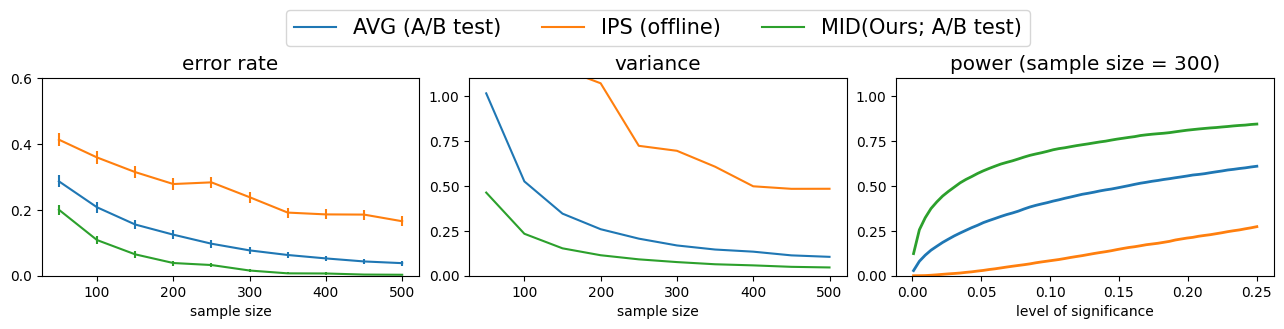

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
plt.rcParams["font.size"] = 12
for est_name in ["AVG", "IPS", "MID"]:#est_list:
    mask_est = result_df["est"] == est_name
    result_dict = {
        "error rate": [],
        "error rate upper": [],
        "error rate lower": [],
        "error rate interval": [],
        "squared_bias": [],
        "variance": [],
        "MSE": [],
    }
    
    for n_data in n_data_list:
        mask_n_data = result_df["n_data"] == n_data
        mask = mask_est & mask_n_data
        result = result_df[mask].copy()
        performance = evaluate_performance(result)
        
        result["delta_value"] = result["pi_1_value"] - result["pi_m_D_1_value"] + result["pi_m_D_0_value"] - result["pi_0_value"]
        est_selection = result["delta_value"] > 0
        m, e, d = np.mean(est_selection), stats.sem(est_selection), len(est_selection) - 1
        interval = stats.t.interval(0.95, d, loc=m, scale=e)
        
        result_dict["error rate"].append(1.0-performance["accuracy"])
        result_dict["error rate lower"].append(1.0-interval[0])
        result_dict["error rate upper"].append(1.0-interval[1])
        result_dict["error rate interval"].append(interval[1]-interval[0])
        result_dict["squared_bias"].append(performance["squared_bias"])
        result_dict["variance"].append(performance["variance"])
        result_dict["MSE"].append(performance["MSE"])
    
    axes[0].errorbar(n_data_list, result_dict["error rate"], yerr=result_dict["error rate interval"], label=f"{est_name}")
    axes[0].set_ylim(0.0, 0.60)
    axes[0].set_xlabel("sample size")
    axes[0].set_title("error rate")
    
    axes[1].plot(n_data_list, result_dict["variance"], label=f"{est_name}")
    axes[1].set_xlabel("sample size")
    axes[1].set_title("variance")
    axes[1].set_ylim(0, 1.1)
    
    mask_n_data = result_df["n_data"] == 300
    mask = mask_est & mask_n_data
    result = result_df[mask].copy()
    
    alpha_grid = np.linspace(0.001, 0.25, 60)
    power = np.array([(result["p_value"] < alpha).mean() for alpha in alpha_grid])
    axes[2].plot(alpha_grid, power, label=f'{est_name}', lw=2)
    axes[2].set_title(f"power (sample size = {300})")
    axes[2].set_xlabel("level of significance")
    axes[2].set_ylim(0, 1.1)

plt.tight_layout()
axes[1].legend(["AVG (A/B test)", "IPS (offline)", "MID(Ours; A/B test)"], loc="upper center", bbox_to_anchor=(0.5, 1.40), ncol=3, fontsize=15)
plt.show()

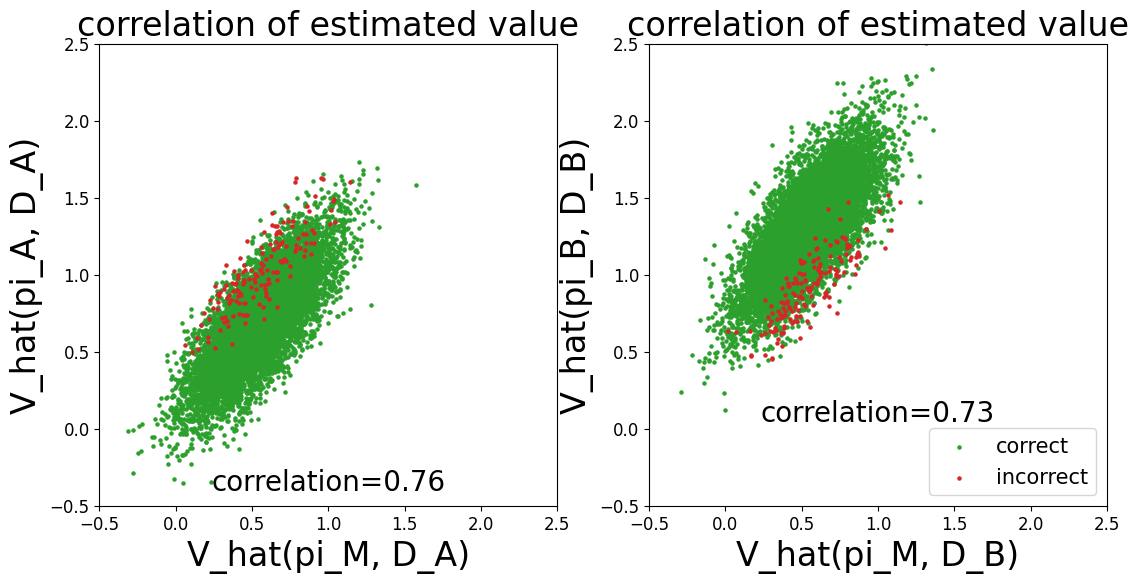

In [7]:
s = 5.0
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
est = "MID"

mask_est = result_df['est'] == est
mask_sample_size = result_df['n_data'] == 300
mask_correct = result_df['selection'] == True
mask_incorrect = result_df['selection'] == False

mask = mask_est & mask_sample_size & mask_correct
result = result_df[mask].copy().reset_index(drop=True)
y = result["pi_0_value"]
x = result["pi_m_D_0_value"]
axes[0].scatter(x, y, color='tab:green', label='correct', s=s)
mask = mask_est & mask_sample_size & mask_incorrect
result = result_df[mask].copy().reset_index(drop=True)
y = result["pi_0_value"]
x = result["pi_m_D_0_value"]
axes[0].scatter(x, y, color='tab:red', label='incorrect', s=s)
corr = np.corrcoef(result_df[mask_est & mask_sample_size]["pi_0_value"], result_df[mask_est & mask_sample_size]["pi_m_D_0_value"])[0, 1]
axes[0].text(0.5, 0.05, f"correlation={corr:.2f}", transform=axes[0].transAxes, ha='center', va='center', fontsize=20)
axes[0].set_xlabel('V_hat(pi_M, D_A)', fontsize=24)
axes[0].set_ylabel('V_hat(pi_A, D_A)', fontsize=24)
axes[0].set_title('correlation of estimated value', fontsize=24)

mask = mask_est & mask_sample_size & mask_correct
result = result_df[mask].copy().reset_index(drop=True)
y = result["pi_1_value"]
x = result["pi_m_D_1_value"]
axes[1].scatter(x, y, color='tab:green', label='correct', s=s)
mask = mask_est & mask_sample_size & mask_incorrect
result = result_df[mask].copy().reset_index(drop=True)
y = result["pi_1_value"]
x = result["pi_m_D_1_value"]
axes[1].scatter(x, y, color='tab:red', label='incorrect', s=s)
corr = np.corrcoef(result_df[mask_est & mask_sample_size]["pi_1_value"], result_df[mask_est & mask_sample_size]["pi_m_D_1_value"])[0, 1]
axes[1].text(0.5, 0.2, f"correlation={corr:.2f}", transform=axes[1].transAxes, ha='center', va='center', fontsize=20)
axes[1].set_xlabel('V_hat(pi_M, D_B)', fontsize=24)
axes[1].set_ylabel('V_hat(pi_B, D_B)', fontsize=24)
axes[1].set_title('correlation of estimated value', fontsize=24)
axes[1].legend(fontsize=15, loc="lower right")

axes[0].set_xlim(-0.5, 2.5)
axes[0].set_ylim(-0.5, 2.5)
axes[1].set_xlim(-0.5, 2.5)
axes[1].set_ylim(-0.5, 2.5)

plt.show()

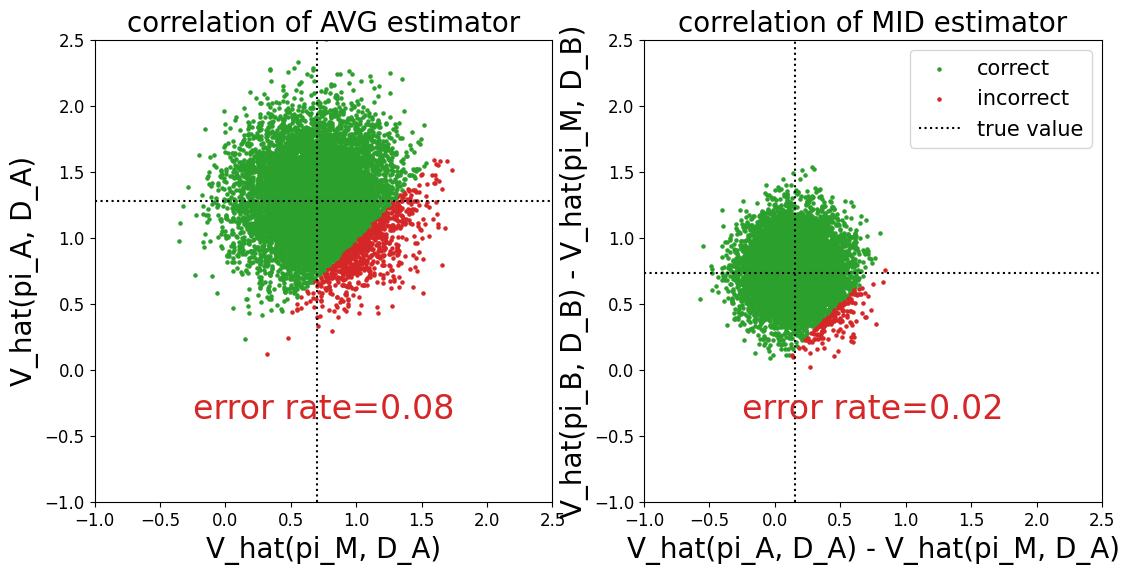

In [8]:
s = 5.0
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
mask_sample_size = result_df['n_data'] == 300
mask_correct = result_df['selection'] == True
mask_incorrect = result_df['selection'] == False

est = "MID"
mask_est = result_df['est'] == est
mask = mask_est & mask_sample_size & mask_correct
result = result_df[mask].copy().reset_index(drop=True)
y = result["pi_1_value"] - result["pi_m_D_1_value"]
x = result["pi_0_value"] - result["pi_m_D_0_value"]
axes[1].scatter(x, y, color='tab:green', label='correct', s=s)
mask = mask_est & mask_sample_size & mask_incorrect
result = result_df[mask].copy().reset_index(drop=True)
y = result["pi_1_value"] - result["pi_m_D_1_value"]
x = result["pi_0_value"] - result["pi_m_D_0_value"]
axes[1].scatter(x, y, color='tab:red', label='incorrect', s=s)
mask = mask_est & mask_sample_size
acc_mid = result_df.loc[mask, "selection"].mean()
axes[1].text(0.5, 0.2, f"error rate={1-acc_mid:.2f}", transform=axes[1].transAxes, ha='center', va='center', fontsize=24, color='tab:red')

true_pi_0_value = result_df['true_pi_0_value'].values[0]
true_pi_m_value = result_df['true_pi_m_value'].values[0]
true_pi_1_value = result_df['true_pi_1_value'].values[0]
axes[1].vlines(true_pi_0_value-true_pi_m_value, ymin=-1.0, ymax=2.5, color='black', linestyles='dotted', label="true value")
axes[1].hlines(true_pi_1_value-true_pi_m_value, xmin=-1.0, xmax=2.5, color='black', linestyles='dotted')

axes[1].set_xlim(-1.0, 2.5)
axes[1].set_ylim(-1.0, 2.5)
axes[1].set_xlabel('V_hat(pi_A, D_A) - V_hat(pi_M, D_A)', fontsize=20)
axes[1].set_ylabel('V_hat(pi_B, D_B) - V_hat(pi_M, D_B)', fontsize=20)
axes[1].set_title('correlation of MID estimator', fontsize=20)
axes[1].legend(fontsize=15)


est = "AVG"
mask_est = result_df['est'] == est

mask = mask_est & mask_sample_size & mask_incorrect
result = result_df[mask].copy().reset_index(drop=True)
y = result["pi_1_value"] - result["pi_m_D_1_value"]
x = result["pi_0_value"] - result["pi_m_D_0_value"]
axes[0].scatter(x, y, color='tab:red', label='incorrect', s=s)

mask = mask_est & mask_sample_size & mask_correct
result = result_df[mask].copy().reset_index(drop=True)
y = result["pi_1_value"] - result["pi_m_D_1_value"]
x = result["pi_0_value"] - result["pi_m_D_0_value"]
axes[0].scatter(x, y, color='tab:green', label='correct', s=s)

mask = mask_est & mask_sample_size
acc_avg = result_df.loc[mask, "selection"].mean()
axes[0].text(0.5, 0.2, f"error rate={1-acc_avg:.2f}", transform=axes[0].transAxes, ha='center', va='center', fontsize=24, color='tab:red')

true_pi_0_value = result_df['true_pi_0_value'].values[0]
true_pi_m_value = result_df['true_pi_m_value'].values[0]
true_pi_1_value = result_df['true_pi_1_value'].values[0]
axes[0].vlines(true_pi_0_value, ymin=-1.0, ymax=2.5, color='black', linestyles='dotted', label="true value")
axes[0].hlines(true_pi_1_value, xmin=-1.0, xmax=2.5, color='black', linestyles='dotted')

axes[0].set_xlim(-1.0, 2.5)
axes[0].set_ylim(-1.0, 2.5)
axes[0].set_xlabel('V_hat(pi_M, D_A)', fontsize=20)
axes[0].set_ylabel('V_hat(pi_A, D_A)', fontsize=20)
axes[0].set_title('correlation of AVG estimator', fontsize=20)
plt.show()